# Problem Statement

Customer churn merupakan salah satu tantangan utama dalam industri telekomunikasi, di mana biaya untuk mempertahankan pelanggan lama jauh lebih rendah dibandingkan memperoleh pelanggan baru.
Perusahaan menghadapi kesulitan dalam mengidentifikasi pelanggan yang berisiko churn serta memahami faktor-faktor utama yang mendorong keputusan pelanggan untuk berhenti berlangganan.

Tanpa pemahaman yang jelas mengenai karakteristik pelanggan yang churn dan faktor-faktor yang memengaruhinya, perusahaan berpotensi kehilangan pendapatan secara berkelanjutan dan gagal merancang strategi retensi yang efektif.

# Objective

Tujuan dari proyek ini adalah untuk:
Menganalisis pola dan karakteristik pelanggan yang mengalami churn berdasarkan data historis.

Mengidentifikasi faktor-faktor utama yang berkontribusi terhadap churn, dengan fokus pada variabel yang actionable dan dapat dipengaruhi oleh kebijakan bisnis.

Memberikan insight berbasis data yang dapat digunakan oleh perusahaan untuk:
Merancang strategi retensi pelanggan
Mengurangi tingkat churn
Meningkatkan nilai jangka panjang pelanggan (customer lifetime value)

# Variables

A. Customer Demographics
customerID – ID unik pelanggan
gender – Jenis kelamin pelanggan
SeniorCitizen – Apakah pelanggan merupakan warga senior (0 = Tidak, 1 = Ya)
Partner – Status memiliki pasangan
Dependents – Status memiliki tanggungan

B. Subscription & Account Information
tenure – Lama pelanggan berlangganan (dalam bulan)
Contract – Jenis kontrak (Month-to-month, One year, Two year)
PaperlessBilling – Apakah menggunakan tagihan paperless
PaymentMethod – Metode pembayaran

C. Services Used
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies

D. Charges
MonthlyCharges – Biaya bulanan yang dibayarkan pelanggan
TotalCharges – Total biaya yang telah dibayarkan selama masa berlangganan

E. Target Variable
Churn – Menunjukkan apakah pelanggan berhenti berlangganan (Yes / No)

# Data for Prediction

Dataset ini adalah:
📌 Statis (Snapshot dataset)
Tidak ada kolom timestamp, 
Tidak ada urutan waktu per customer, 
Data merepresentasikan kondisi pelanggan pada satu titik waktu

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Understanding & Preparation

## Checking Mising Value & Duplicated

In [90]:
print(f'Total Dupilcated Data : {df.duplicated().sum()}')

Total Dupilcated Data : 0


In [91]:
print(f'Missing Value : \n{df.isnull().sum()}')

Missing Value : 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [92]:
df[df['TotalCharges'] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [93]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [94]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges']]

,tenure,MonthlyCharges
488,0,52.55
753,0,20.25
936,0,80.85
1082,0,25.75
1340,0,56.05
3331,0,19.85
3826,0,25.35
4380,0,20.00
5218,0,19.70
6670,0,73.35


## Handling Missing Values

In [95]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [97]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Hypothesis Awal (Pre-Model Thinking)

Customer dengan tenure rendah lebih rentan churn.

Contract tipe month-to-month lebih rentan churn dibanding yearly contract.

MonthlyCharges tinggi bisa meningkatkan risiko churn.

Customer tanpa TechSupport / OnlineSecurity lebih rentan churn.

<Axes: xlabel='Churn', ylabel='count'>

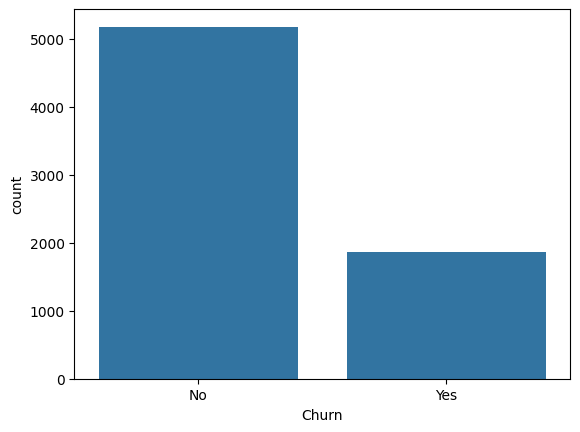

In [98]:
sns.countplot(x='Churn', data=df)

In [99]:
churn_tenure = df.groupby('Churn')['tenure'].mean()
churn_tenure

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

<Axes: xlabel='Churn', ylabel='tenure'>

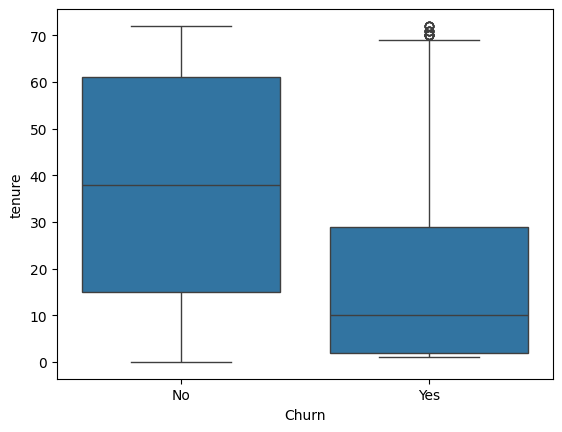

In [100]:
sns.boxplot(x='Churn', y='tenure', data=df)

In [101]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='Contract', ylabel='count'>

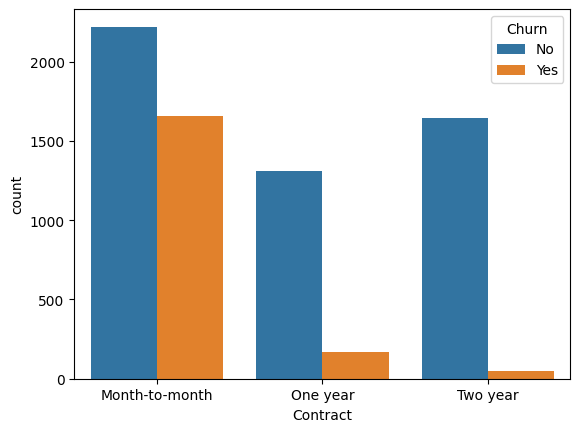

In [102]:
sns.countplot(x='Contract', hue='Churn', data=df)

In [103]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


Customer yang churn rata-rata bayar lebih mahal ±13 dollar per bulan.

Median lebih tahan terhadap outlier dibanding mean.

Jadi pola ini konsisten, bukan karena beberapa nilai ekstrem.

Customer non-churn banyak di rentang biaya rendah (25–60).

Customer churn lebih terkonsentrasi di biaya menengah–tinggi.

## Feautre Preparation

In [104]:
# Drop Feature yang Tidak Relevan
X = df.copy()
y = df['Churn']
X = X.drop(columns=['customerID', 'Churn'], errors='ignore')

In [105]:
# Encoding Churn
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y[:5]

array([0, 0, 1, 0, 1])

In [106]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [107]:
X = pd.get_dummies(X, drop_first=True)
cols_boolean = X.select_dtypes(include='bool').columns
X[cols_boolean] = X[cols_boolean].astype(int)

## Dataset

In [108]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [109]:
y[:10]

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

# Splitting Train-Test Data

In [110]:
from sklearn.model_selection import train_test_split

# Split dataset to Train and Test
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [111]:
print(f'X_train : {X_train.shape}\n')
print(f'y_train : {y_train.shape}\n')
print(f'X_test : {X_test.shape}\n')
print(f'y_test : {y_test.shape}')

X_train : (5634, 30)

y_train : (5634,)

X_test : (1409, 30)

y_test : (1409,)


In [112]:
print(f'Mean Y Train : {y_train.mean()}')
print(f'Mean Y Test : {y_test.mean()}')

Mean Y Train : 0.2653532126375577
Mean Y Test : 0.2654364797728886


## Scaling Dataset

In [113]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [114]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])


# Modeling

## Logistic Regression

In [115]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [116]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# Evaluation

## Logistic Regression

In [117]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score : {accuracy:.2f}')

Accuracy Score : 0.81


In [118]:
# 2. Precision , Recall, F1-Score
print('Classification Report :')
print(classification_report(y_test, y_pred))


Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [119]:
# 3. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)
print(f'ROC-AUC Score : {roc_auc:.2f}')

ROC-AUC Score : 0.73


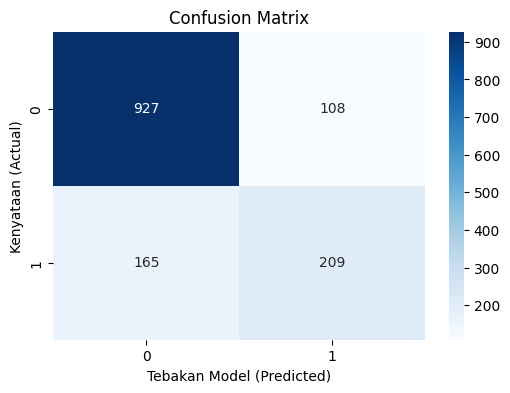

In [120]:
# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix')
plt.show()

### Improvement

In [121]:
y_pred_03 = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [122]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score : {roc_auc:.3f}')

ROC-AUC Score : 0.842


By lowering the classification threshold from 0.5 to 0.3, recall improved significantly from 56% to 76%, allowing the model to capture more potential churn customers. Although precision decreased, this trade-off is acceptable in a customer retention strategy where missing a churn customer is more costly than offering unnecessary promotions.

### Insight Extraction

In [123]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': model.coef_[0]
})

In [124]:
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])

coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df.head(10)

,feature,coefficient,odds_ratio,abs_coef
25,Contract_Two year,-1.313803,0.268796,1.313803
1,tenure,-1.257131,0.284469,1.257131
10,InternetService_Fiber optic,1.180666,3.256541,1.180666
24,Contract_One year,-0.683857,0.504667,0.683857
3,TotalCharges,0.527772,1.695151,0.527772
7,PhoneService_Yes,-0.520750,0.594075,0.520750
2,MonthlyCharges,-0.466504,0.627191,0.466504
28,PaymentMethod_Electronic check,0.392775,1.481085,0.392775
21,StreamingTV_Yes,0.374831,1.454745,0.374831
26,PaperlessBilling_Yes,0.374218,1.453853,0.374218


In [125]:
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

coef_df.head(10)

,feature,coefficient,odds_ratio,abs_coef
10,InternetService_Fiber optic,1.180666,3.256541,1.180666
3,TotalCharges,0.527772,1.695151,0.527772
28,PaymentMethod_Electronic check,0.392775,1.481085,0.392775
21,StreamingTV_Yes,0.374831,1.454745,0.374831
26,PaperlessBilling_Yes,0.374218,1.453853,0.374218
23,StreamingMovies_Yes,0.373193,1.452365,0.373193
9,MultipleLines_Yes,0.361646,1.435691,0.361646
0,SeniorCitizen,0.147911,1.159410,0.147911
29,PaymentMethod_Mailed check,0.081866,1.085310,0.081866
17,DeviceProtection_Yes,0.033106,1.033660,0.033106


In [126]:
coef_df.sort_values(by='coefficient', ascending=True).head(10)

,feature,coefficient,odds_ratio,abs_coef
25,Contract_Two year,-1.313803,0.268796,1.313803
1,tenure,-1.257131,0.284469,1.257131
24,Contract_One year,-0.683857,0.504667,0.683857
7,PhoneService_Yes,-0.520750,0.594075,0.520750
2,MonthlyCharges,-0.466504,0.627191,0.466504
13,OnlineSecurity_Yes,-0.349144,0.705292,0.349144
19,TechSupport_Yes,-0.299256,0.741370,0.299256
8,MultipleLines_No phone service,-0.269330,0.763891,0.269330
6,Dependents_Yes,-0.226396,0.797402,0.226396
22,StreamingMovies_No internet service,-0.172521,0.841540,0.172521


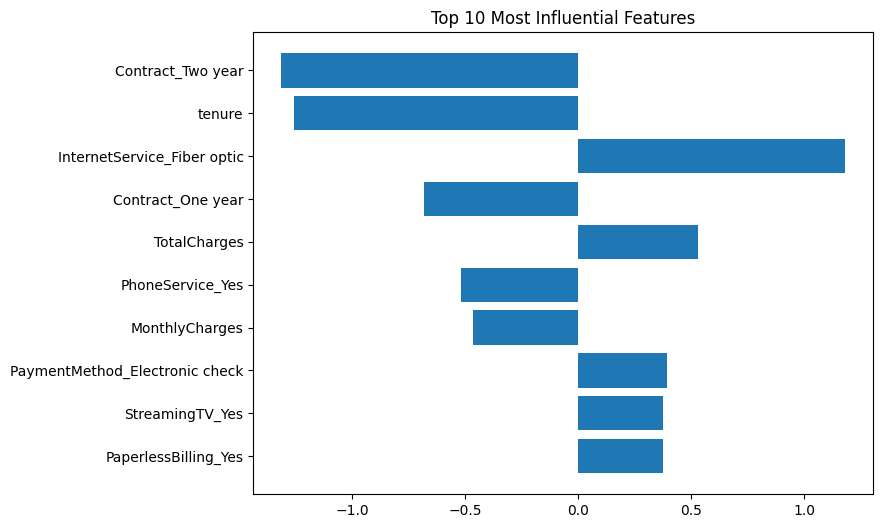

In [127]:
top_features = coef_df.sort_values(by='abs_coef', ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['coefficient'])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Influential Features")
plt.show()

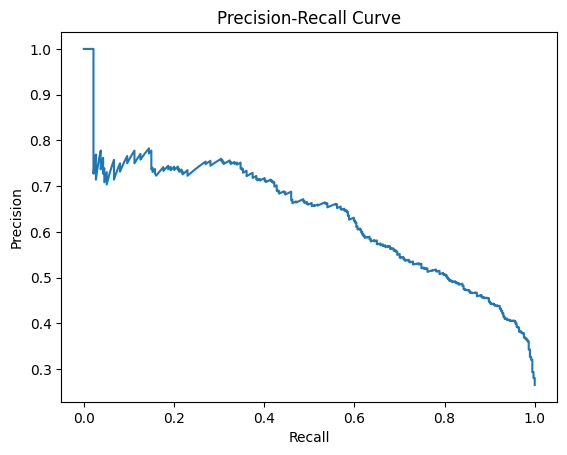

In [128]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [129]:
from sklearn.metrics import recall_score, precision_score
thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_temp)
    precision = precision_score(y_test, y_pred_temp)
    print(f"Threshold: {t:.2f} | Recall: {recall:.2f} | Precision: {precision:.2f}")

Threshold: 0.10 | Recall: 0.95 | Precision: 0.41
Threshold: 0.15 | Recall: 0.91 | Precision: 0.44
Threshold: 0.20 | Recall: 0.86 | Precision: 0.47
Threshold: 0.25 | Recall: 0.81 | Precision: 0.50
Threshold: 0.30 | Recall: 0.76 | Precision: 0.52
Threshold: 0.35 | Recall: 0.70 | Precision: 0.54
Threshold: 0.40 | Recall: 0.67 | Precision: 0.57
Threshold: 0.45 | Recall: 0.61 | Precision: 0.60
Threshold: 0.50 | Recall: 0.56 | Precision: 0.66
Threshold: 0.55 | Recall: 0.46 | Precision: 0.68
Threshold: 0.60 | Recall: 0.40 | Precision: 0.72
Threshold: 0.65 | Recall: 0.31 | Precision: 0.75
Threshold: 0.70 | Recall: 0.19 | Precision: 0.74
Threshold: 0.75 | Recall: 0.08 | Precision: 0.74
Threshold: 0.80 | Recall: 0.03 | Precision: 0.77
Threshold: 0.85 | Recall: 0.00 | Precision: 1.00


# Risk-Based Targeting Strategy

### Case Problems
Budget retention campaign cuma cukup untuk 30% customer.

In [133]:
df_test = X_test.copy()
df_test['actual'] = y_test
df_test['prob_churn'] = y_prob

df_test_sorted = df_test.sort_values(by='prob_churn', ascending=False)

In [137]:
# Ambil Top 30%
top_30_percent = int(0.3 * len(df_test_sorted))
df_target = df_test_sorted.head(top_30_percent)

In [138]:
recall_top30 = df_target['actual'].sum() / y_test.sum()
print("Recall @ Top 30%:", recall_top30)

Recall @ Top 30%: 0.6497326203208557


“However, in real business settings, targeting is often budget-constrained. Therefore, we also evaluate a Top 30% risk-based strategy.”

While threshold tuning improved recall, a ranking-based targeting strategy is more aligned with real-world budget constraints. By targeting the top 30% highest-risk customers, the model captures 65% of churners, achieving ~2.1x lift compared to random targeting.

In [155]:
pd.Series(y_test).value_counts()

0    1035
1     374
Name: count, dtype: int64